# Ini adalah Skenario 1 Flight dataset menggunakan algoritma XGBoost
## Skenario 1 adalah PRE-FLIGHT PREDICTION
### Dengan Tujuan prediksi delay SEBELUM pesawat berangkat

In [ ]:
# Import Library

import kagglehub

# Download latest version
path = kagglehub.dataset_download("hrishitpatil/flight-data-2024")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'flight-data-2024' dataset.
Path to dataset files: /kaggle/input/flight-data-2024


In [ ]:
# Import file

import os
print(os.listdir(path))

['flight_data_2024_sample.csv', 'flight_data_2024_data_dictionary.csv', 'flight_data_2024.csv']


In [ ]:
# Pengecekan data

import pandas as pd

# Sesuaikan nama file dari hasil Step 1
df = pd.read_csv(f"{path}/flight_data_2024.csv")

print("\n===== RINGKASAN DATASET =====")
print(f"Total Baris     : {df.shape[0]:,}")
print(f"Total Kolom     : {df.shape[1]}")
print(f"Total Sel Data  : {df.size:,}")
print(f"Ukuran Memori   : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

/tmp/ipykernel_19487/4027671819.py:6: DtypeWarning: Columns (24) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f"{path}/flight_data_2024.csv")



===== RINGKASAN DATASET =====
Total Baris     : 7,079,081
Total Kolom     : 35
Total Sel Data  : 247,767,835
Ukuran Memori   : 4676.93 MB


In [ ]:
# Pengecekan kualitas Data

print("===== KUALITAS DATA =====")
print(f"Missing Values per Kolom:")
print(df.isnull().sum())
print(f"\nTotal Missing Values: {df.isnull().sum().sum():,}")
print(f"Tipe Data:")
print(df.dtypes)

===== KUALITAS DATA =====
Missing Values per Kolom:
year                         0
month                        0
day_of_month                 0
day_of_week                  0
fl_date                      0
op_unique_carrier            0
op_carrier_fl_num            1
origin                       0
origin_city_name             0
origin_state_nm              0
dest                         0
dest_city_name               0
dest_state_nm                0
crs_dep_time                 0
dep_time                 92659
dep_delay                92970
taxi_out                 95734
wheels_off               95734
wheels_on                97856
taxi_in                  97856
crs_arr_time                 0
arr_time                 97854
arr_delay               113814
cancelled                    0
cancellation_code      6982766
diverted                     0
crs_elapsed_time             1
actual_elapsed_time     113814
air_time                113814
distance                     0
carrier_delay     

In [ ]:
# Sample data

df.head()

,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2024,1,1,1,2024-01-01,9E,4814.0,JFK,"New York, NY",New York,...,0,136.0,122.0,84.0,509.0,0,0,0,0,0
1,2024,1,1,1,2024-01-01,9E,4815.0,MSP,"Minneapolis, MN",Minnesota,...,0,130.0,114.0,88.0,622.0,0,0,0,0,0
2,2024,1,1,1,2024-01-01,9E,4817.0,JFK,"New York, NY",New York,...,0,106.0,90.0,61.0,288.0,0,0,0,0,0
3,2024,1,1,1,2024-01-01,9E,4817.0,RIC,"Richmond, VA",Virginia,...,0,111.0,76.0,51.0,288.0,0,0,0,0,0
4,2024,1,1,1,2024-01-01,9E,4818.0,DTW,"Detroit, MI",Michigan,...,0,79.0,70.0,45.0,237.0,0,0,0,0,0


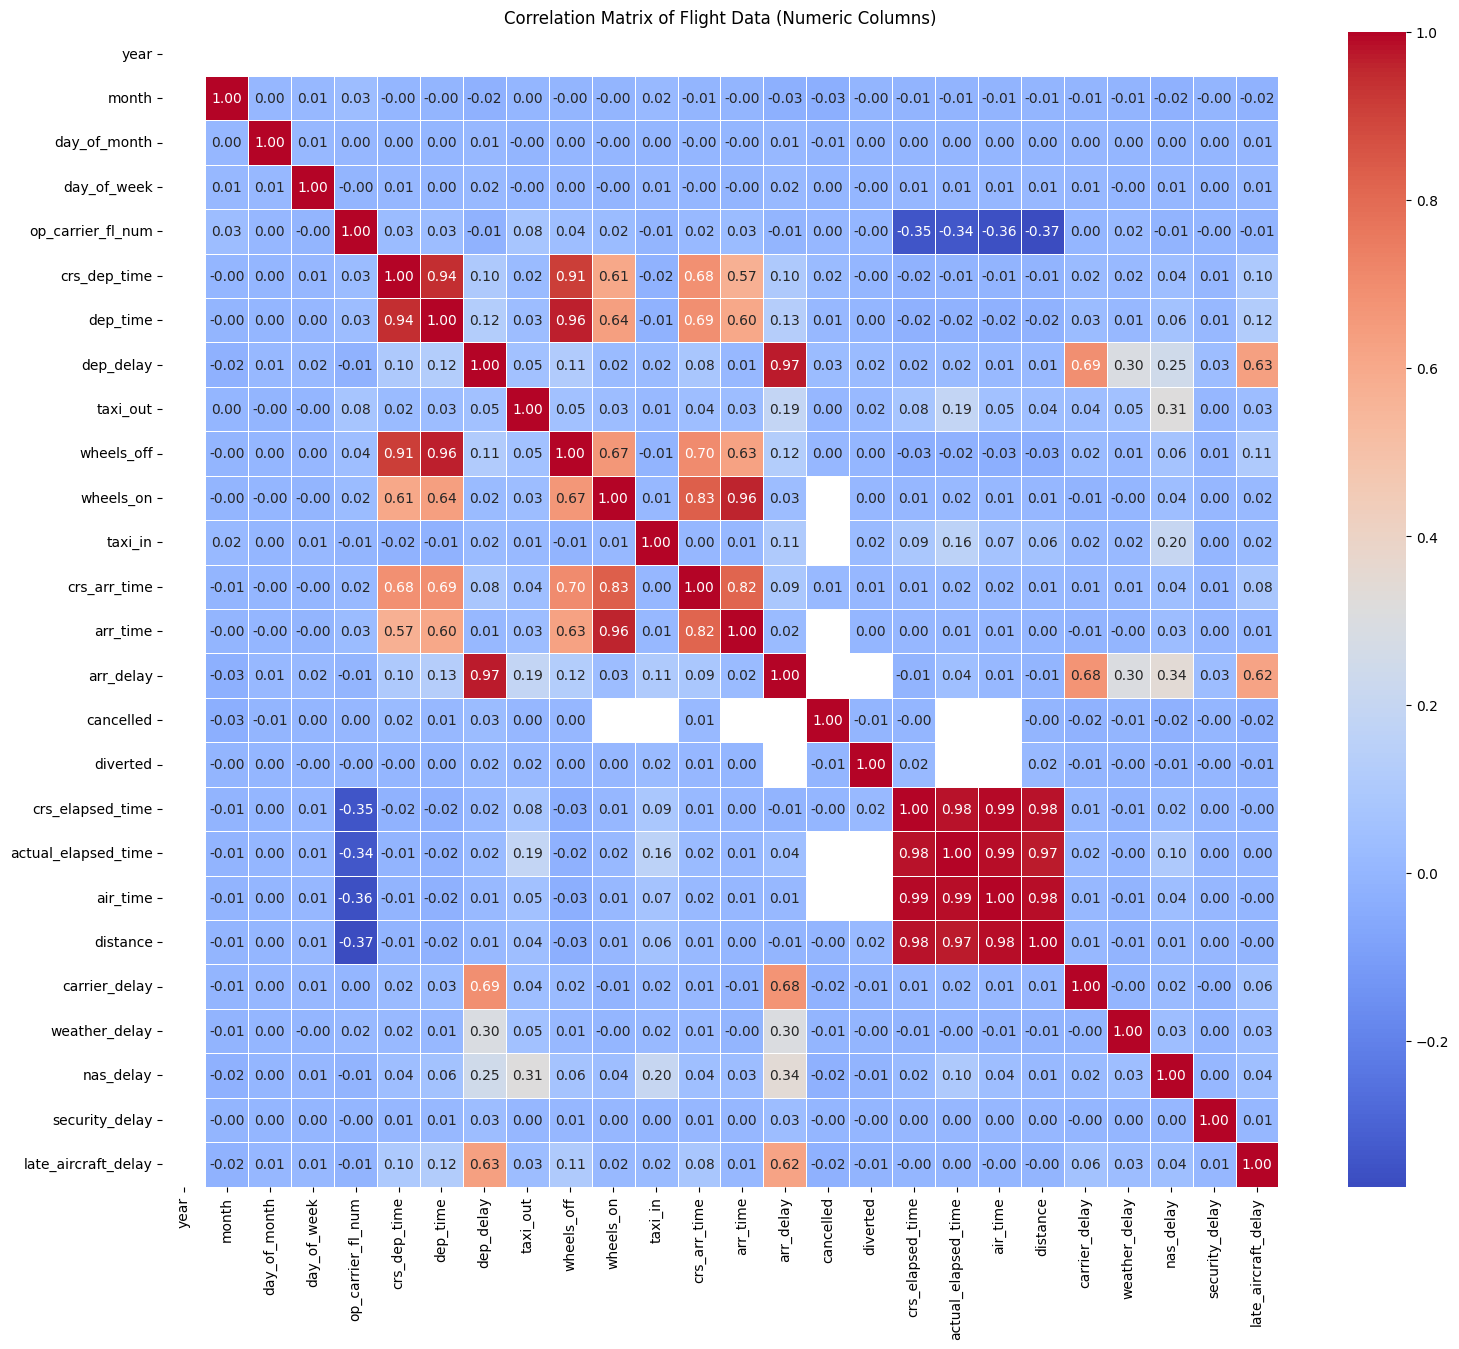

In [ ]:
# Pengecekan correlation Matriks

import matplotlib.pyplot as plt
import seaborn as sns

correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(18, 15))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5)
plt.title('Correlation Matrix of Flight Data (Numeric Columns)')
plt.show()

## Preproses Skenario 1

In [ ]:
# Pemisahan target

df = df[df['cancelled'] == 0]
df = df[df['diverted'] == 0]

df['is_delayed'] = (
    df['dep_delay'] > 15
).astype(int)

In [ ]:
# Pemilihan fitur untuk kebutuhan skenario

keep_cols = [
    # tanggal
    'month',
    'day_of_month',
    'day_of_week',

    # airline
    'op_unique_carrier',
    'op_carrier_fl_num',

    # lokasi
    'origin',
    'origin_state_nm',

    'dest',
    'dest_state_nm',

    # actual departure info
    'crs_dep_time',
    'crs_arr_time',

    # Flight Info
    'distance'
]

In [ ]:
# Pemisahan Fitur dan target

X = df[keep_cols].copy()
y = df['is_delayed']

In [ ]:
# Imputasi missing values

X['op_carrier_fl_num'] = X['op_carrier_fl_num'].fillna(0)

In [ ]:
# Encoding Waktu

def convert_time(x):
    if pd.isna(x):
        return np.nan

    x = int(x)
    hour = x // 100
    minute = x % 100
    return hour * 60 + minute

X['crs_dep_time'] = X['crs_dep_time'].apply(convert_time)
X['crs_arr_time'] = X['crs_arr_time'].apply(convert_time)

In [ ]:
# Label Encoding

from sklearn.preprocessing import LabelEncoder

cat_cols = [
    'op_unique_carrier',
    'origin',
    'origin_state_nm',
    'dest',
    'dest_state_nm'
]

for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

In [ ]:
# Cek Distribusi Target

y.value_counts(normalize=True)

,proportion
is_delayed,
0,0.800598
1,0.199402


In [ ]:
# Splitting

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:
X.head()

,month,day_of_month,day_of_week,op_unique_carrier,op_carrier_fl_num,origin,origin_state_nm,dest,dest_state_nm,crs_dep_time,crs_arr_time,distance
0,1,1,1,0,4814.0,173,30,98,20,772,908,509.0
1,1,1,1,0,4815.0,227,21,67,33,615,805,622.0
2,1,1,1,0,4817.0,173,30,275,47,855,961,288.0
3,1,1,1,0,4817.0,275,47,173,30,1010,1121,288.0
4,1,1,1,0,4818.0,98,20,217,50,615,634,237.0


## Train XGBoost

In [ ]:
# Pengaturan Model

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=4,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

In [ ]:
# Train model

xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)

In [ ]:
# Predict berdasarkan splitting tadi

y_pred = xgb_model.predict(X_test)

In [ ]:
# Evaluasi Model

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.69      0.78   1115277
           1       0.35      0.67      0.46    277777

    accuracy                           0.68   1393054
   macro avg       0.62      0.68      0.62   1393054
weighted avg       0.78      0.68      0.71   1393054



### Opsional

Top Korelasi Skenario 1:
crs_dep_time         0.185863
crs_arr_time         0.147119
day_of_week          0.029840
distance             0.019498
day_of_month         0.010127
dest                 0.005846
origin_state_nm      0.003299
dest_state_nm       -0.000277
origin              -0.017549
op_unique_carrier   -0.022084
op_carrier_fl_num   -0.024498
month               -0.031213
Name: is_delayed, dtype: float64


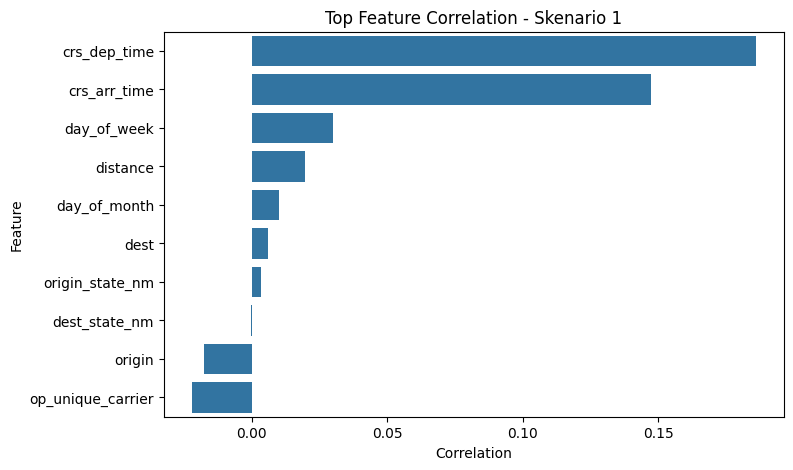

In [ ]:
# Pengecekan Feature Importance

from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# fitur skenario 1
preflight_cols = [
    # tanggal
    'month',
    'day_of_month',
    'day_of_week',

    # airline
    'op_unique_carrier',
    'op_carrier_fl_num',

    # lokasi
    'origin',
    'origin_state_nm',

    'dest',
    'dest_state_nm',

    # actual departure info
    'crs_dep_time',
    'crs_arr_time',

    # Flight Info
    'distance',

    'is_delayed'
]

# copy dataset
df_pre = df[preflight_cols].copy()

# encode categorical
cat_cols = [
    'op_unique_carrier',
    'origin',
    'origin_state_nm',
    'dest',
    'dest_state_nm'
]

le = LabelEncoder()

for col in cat_cols:
    df_pre[col] = le.fit_transform(df_pre[col].astype(str))

# correlation matrix
corr_pre = df_pre.corr()

# korelasi ke target
target_corr_pre = (
    corr_pre['is_delayed']
    .drop('is_delayed')
    .sort_values(ascending=False)
)

print("Top Korelasi Skenario 1:")
print(target_corr_pre)

# visualisasi top 10
top_pre = target_corr_pre.head(10)

plt.figure(figsize=(8,5))
sns.barplot(
    x=top_pre.values,
    y=top_pre.index
)
plt.title("Top Feature Correlation - Skenario 1")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.show()

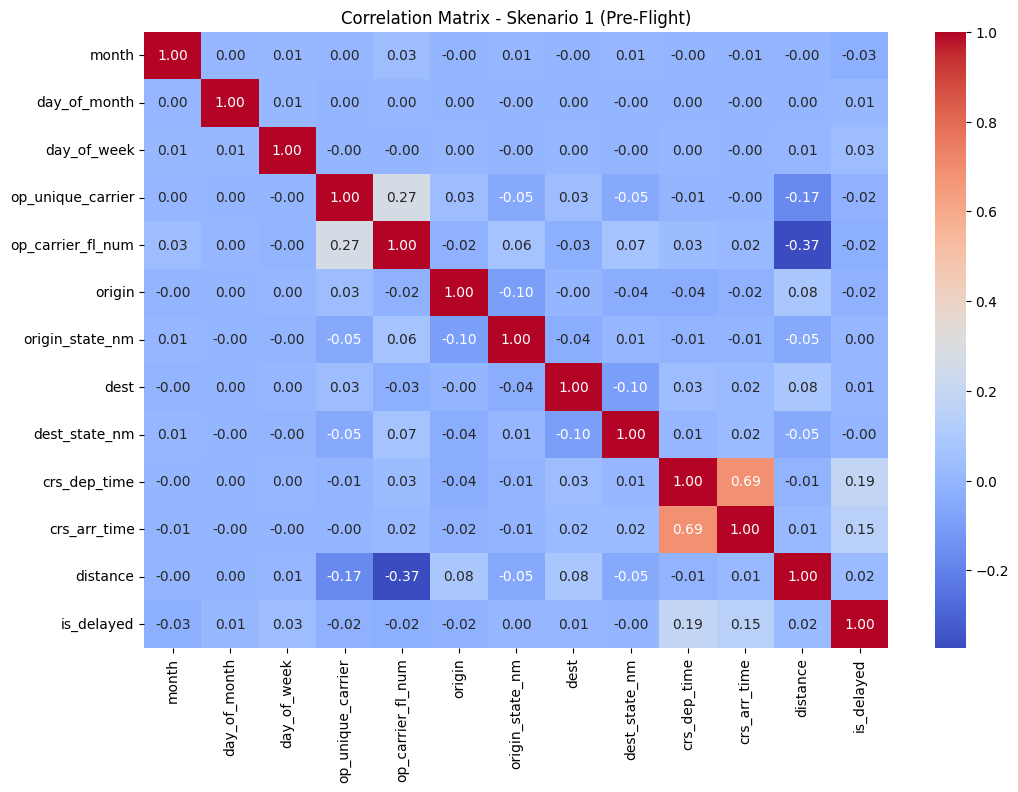

In [ ]:
# Pengecekan Korelasi fitur akhir (Hiraukan Saja)

from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# fitur skenario 1
preflight_cols = [
    # tanggal
    'month',
    'day_of_month',
    'day_of_week',

    # airline
    'op_unique_carrier',
    'op_carrier_fl_num',

    # lokasi
    'origin',
    'origin_state_nm',

    'dest',
    'dest_state_nm',

    # actual departure info
    'crs_dep_time',
    'crs_arr_time',

    # Flight Info
    'distance',

    'is_delayed'
]

df_pre = df[preflight_cols].copy()

# encode categorical
cat_cols = [
    'op_unique_carrier',
    'origin',
    'origin_state_nm',
    'dest',
    'dest_state_nm'
]

le = LabelEncoder()
for col in cat_cols:
    df_pre[col] = le.fit_transform(df_pre[col].astype(str))

# correlation matrix
corr_pre = df_pre.corr()

# heatmap
plt.figure(figsize=(12,8))
sns.heatmap(
    corr_pre,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title("Correlation Matrix - Skenario 1 (Pre-Flight)")
plt.show()

In [ ]:
X.describe()

,month,day_of_month,day_of_week,op_unique_carrier,op_carrier_fl_num,origin,origin_state_nm,dest,dest_state_nm,crs_dep_time,crs_arr_time,distance
count,6.965267e+06,6.965267e+06,6.965267e+06,6.965267e+06,6.965267e+06,6.965267e+06,6.965267e+06,6.965267e+06,6.965267e+06,6.965267e+06,6.965267e+06,6.965267e+06
mean,6.597649e+00,1.579056e+01,3.981578e+00,7.831989e+00,2.503914e+03,1.684698e+02,2.181000e+01,1.684876e+02,2.180792e+01,8.064544e+02,9.060774e+02,8.336730e+02
std,3.397294e+00,8.794846e+00,2.012222e+00,4.761863e+00,1.651642e+03,9.362156e+01,1.549394e+01,9.363630e+01,1.549300e+01,2.970462e+02,3.118555e+02,5.963392e+02
min,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.100000e+01
25%,4.000000e+00,8.000000e+00,2.000000e+00,4.000000e+00,1.151000e+03,9.000000e+01,7.000000e+00,9.000000e+01,7.000000e+00,5.450000e+02,6.630000e+02,3.990000e+02
50%,7.000000e+00,1.600000e+01,4.000000e+00,9.000000e+00,2.227000e+03,1.820000e+02,2.000000e+01,1.820000e+02,2.000000e+01,8.000000e+02,9.150000e+02,6.800000e+02
75%,1.000000e+01,2.300000e+01,6.000000e+00,1.200000e+01,3.717000e+03,2.470000e+02,3.600000e+01,2.470000e+02,3.600000e+01,1.055000e+03,1.165000e+03,1.069000e+03
max,1.200000e+01,3.100000e+01,7.000000e+00,1.400000e+01,8.819000e+03,3.470000e+02,5.100000e+01,3.470000e+02,5.100000e+01,1.440000e+03,1.439000e+03,5.095000e+03


## Insight

In [ ]:
# Melihat XGBoost tree paling optimal berdasarkan logloss

# Ambil logloss tiap tree
results = xgb_model.evals_result()

logloss = results["validation_0"]["logloss"]

import pandas as pd

tree_result = pd.DataFrame({
    "tree": range(1, len(logloss) + 1),
    "logloss": logloss
})

# Ambil 10 tree dengan logloss terendah
top10 = (
    tree_result
    .sort_values("logloss")
    .head(10)
    .reset_index(drop=True)
)

print("\n===== TOP 10 TREE TERBAIK =====")
print(top10)

best_tree = int(top10.iloc[0]["tree"])

print(f"\nBest Tree: {best_tree}")
print(f"Best LogLoss: {top10.iloc[0]['logloss']:.6f}")

# Prediksi ulang pakai best tree
y_pred = xgb_model.predict(
    X_test,
    iteration_range=(0, best_tree)
)


===== TOP 10 TREE TERBAIK =====
   tree   logloss
0   200  0.596885
1   199  0.596906
2   198  0.596990
3   197  0.597015
4   196  0.597042
5   195  0.597093
6   194  0.597158
7   193  0.597164
8   192  0.597208
9   191  0.597261

Best Tree: 200
Best LogLoss: 0.596885


In [ ]:
# Output IF Else (Rule)

booster = xgb_model.get_booster()

tree = booster.get_dump(
    with_stats=True
)

print(
    tree[best_tree - 1]
)

0:[dest<331] yes=1,no=2,missing=2,gain=7.44299984,cover=1517543.25
	1:[op_carrier_fl_num<725] yes=3,no=4,missing=4,gain=6.09712505,cover=1501530.62
		3:[origin<341] yes=7,no=8,missing=8,gain=9.92487431,cover=241264.969
			7:[origin<5] yes=15,no=16,missing=16,gain=9.17756844,cover=240594.109
				15:[op_carrier_fl_num<630] yes=31,no=32,missing=32,gain=15.7467012,cover=1199.72937
					31:[op_carrier_fl_num<590] yes=61,no=62,missing=62,gain=20.5728302,cover=1051.59937
						61:[month<7] yes=121,no=122,missing=122,gain=17.6072407,cover=970.922974
							121:[dest<251] yes=231,no=232,missing=232,gain=17.0738182,cover=540.62738
								231:leaf=0.0291719344,cover=434.946289
								232:leaf=-0.015515442,cover=105.681099
							122:[op_unique_carrier<13] yes=233,no=234,missing=234,gain=17.4429455,cover=430.295563
								233:leaf=-0.0205902066,cover=290.74234
								234:leaf=0.0222977456,cover=139.553207
						62:[crs_arr_time<678] yes=123,no=124,missing=124,gain=20.8238583,cover=80.6763992
	

## Test model 1 bulan ke depan

In [ ]:
df_2025 = pd.read_csv(
    "Januari_2025_1.csv"
)

print(df_2025.shape)

(539747, 13)


In [ ]:
print("===== KUALITAS DATA =====")
print(f"Missing Values per Kolom:")
print(df_2025.isnull().sum())
print(f"\nTotal Missing Values: {df_2025.isnull().sum().sum():,}")
print(f"Tipe Data:")
print(df_2025.dtypes)

===== KUALITAS DATA =====
Missing Values per Kolom:
month                    0
day_of_month             0
day_of_week              0
op_unique_carrier        0
op_carrier_fl_num        0
origin                   0
origin_state_nm          0
dest                     0
dest_state_nm            0
crs_dep_time             0
dep_delay            15923
crs_arr_time             0
distance                 0
dtype: int64

Total Missing Values: 15,923
Tipe Data:
month                  int64
day_of_month           int64
day_of_week            int64
op_unique_carrier     object
op_carrier_fl_num      int64
origin                object
origin_state_nm       object
dest                  object
dest_state_nm         object
crs_dep_time           int64
dep_delay            float64
crs_arr_time           int64
distance               int64
dtype: object


In [ ]:
# target asli (opsional buat evaluasi)
y_real = (
    df_2025["dep_delay"] > 15
).astype(int)

X_new = df_2025[
    keep_cols
].copy()

In [ ]:
X_new["crs_dep_time"] = (
    X_new["crs_dep_time"]
    .apply(convert_time)
)

X_new["crs_arr_time"] = (
    X_new["crs_arr_time"]
    .apply(convert_time)
)

In [ ]:
num_cols = X_new.select_dtypes(
    include=["int64","float64"]
).columns

for col in num_cols:
    X_new[col] = X_new[col].fillna(
        X[col].median()
    )

In [ ]:
cat_cols = [
    'op_unique_carrier',
    'origin',
    'origin_state_nm',
    'dest',
    'dest_state_nm'
]

for col in cat_cols:
    le = LabelEncoder()

    X_new[col] = le.fit_transform(
        X_new[col].astype(str)
    )

In [ ]:
y_pred = xgb_model.predict(
    X_new
)

y_prob = (
    xgb_model
    .predict_proba(X_new)
)[:,1]

In [ ]:
# Evaluasi berdasarkan model dari testing 1 bulan

from sklearn.metrics import (
    classification_report
)

print(
    classification_report(
        y_real,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.85      0.56      0.68    447329
           1       0.20      0.53      0.29     92418

    accuracy                           0.56    539747
   macro avg       0.53      0.55      0.48    539747
weighted avg       0.74      0.56      0.61    539747



In [ ]:
# Correlation Matriks

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_real,
    y_pred
)

print(cm)

[[251783 195546]
 [ 43264  49154]]
